# Sprint 10 - Avaliação Final do Modelo

---

## Etapa 1 - Carregar Artefatos

In [10]:
import pandas as pd
import joblib

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import confusion_matrix
import seaborn as sns

from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/processed/encoded_df.csv')

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = joblib.load('../models/final_model.pkl')
scaler = joblib.load('../models/final_scaler.pkl')

X_test_scaled = scaler.transform(X_test)

---

## Etapa 2 - Métricas Finais

In [5]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall:", recall_score(y_test,y_pred))
print("F1:", f1_score(y_test,y_pred))

Accuracy: 0.7263681592039801
Precision: 0.49093904448105435
Recall: 0.7967914438502673
F1: 0.6075433231396534


---

## Etapa 3 - ROC-AUC

In [6]:
from sklearn.metrics import roc_auc_score

probabilities = model.predict_proba(
    X_test_scaled
)[:,1]

roc_auc = roc_auc_score(
    y_test,
    probabilities
)

print("ROC-AUC:",roc_auc)

ROC-AUC: 0.8349765233911922


---

## Etapa 4 - Curva ROC

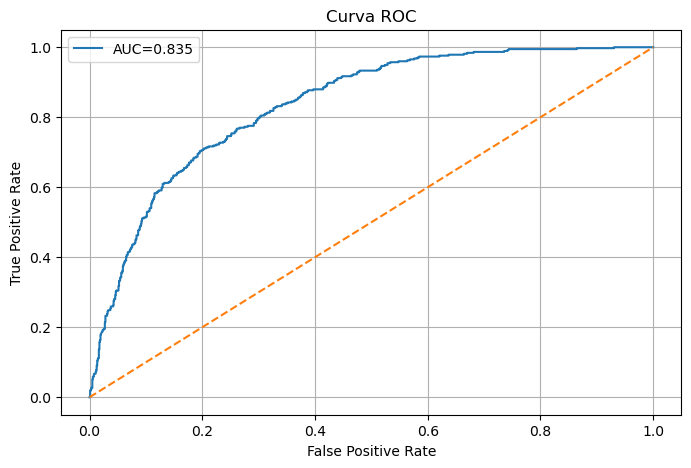

In [12]:
fpr, tpr, _ = roc_curve(
    y_test,
    probabilities
)

plt.figure(figsize=(8,5))

plt.plot(
    fpr,
    tpr,
    label=f'AUC={roc_auc:.3f}'
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Curva ROC")

plt.legend()

plt.grid()

plt.show()

---

## Etapa 5 - Precision Recall Curve

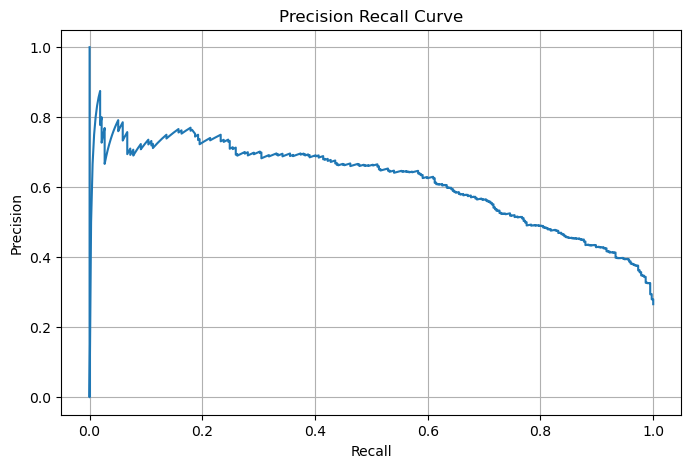

In [11]:
precision, recall, _ = precision_recall_curve(
    y_test,
    probabilities
)

plt.figure(figsize=(8,5))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.grid()

plt.show()

---

## Etapa 6 - Matriz de Confusão

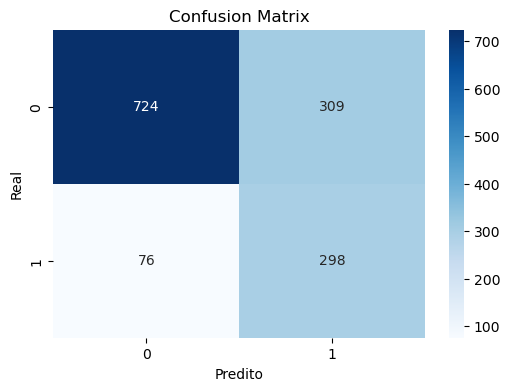

In [13]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predito")
plt.ylabel("Real")

plt.title("Confusion Matrix")

plt.show()